# Gamma GLM Prototype — YRA084 260228

Fit a Gamma GLM to neural calcium imaging data using nemos.

**Sections:**
- A: Load Data
- B: Preprocess — Spatial and Temporal Binning
- C: Design Matrix
- D: Fit GLM
- E: Analyze — Clustering and PCA of weight matrix
- F: Extend — Fos High vs Fos Low analysis

## Section A: Load Data

Copy the h5ad file to our working directory (never modify the original) and load it.

In [2]:
import sys, os
sys.path.insert(0, '/home/akj290/code/glm/scripts')

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nemos as nmo
import jax
import jax.numpy as jnp
import shutil
from pathlib import Path
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tqdm import tqdm

from preprocess import bin_adata_loop, bin_adata_vectorized

jax.config.update("jax_enable_x64", True)

# Copy data to output directory (do not modify original)
src_path = '/n/data2/hms/neurobio/harvey/yasmine/data/imaging/YRA084/260306/session_1/adata_maximin.h5ad'
out_dir = '/n/data2/hms/neurobio/harvey/akshay/data/glm/YRA084/260306/session_1'
os.makedirs(out_dir, exist_ok=True)
dst_path = os.path.join(out_dir, 'adata_maximin.h5ad')
if not os.path.exists(dst_path):
    shutil.copy2(src_path, dst_path)

adata = ad.read_h5ad(dst_path)
print(f"Loaded adata: {adata.shape}")
print(f"Volume rate: {adata.uns['metadata']['volume_rate']:.2f} Hz")
print(f"Layers: {list(adata.layers.keys())}")
print(f"Y range (dcnv_norm): {adata.layers['dcnv_norm'].min():.3f} to {adata.layers['dcnv_norm'].max():.3f}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"var columns: {list(adata.var.columns)}")

Loaded adata: (97116, 456)
Volume rate: 29.98 Hz
Layers: ['dF', 'dcnv', 'dcnv_0.25sigma', 'dcnv_0.25sigma_norm', 'dcnv_norm']
Y range (dcnv_norm): 0.000 to 79.540
obs columns: ['pitch', 'roll', 'yaw', 'sync_reward', 't', 'dt', 'world_id', 'dx', 'dy', 'dh', 'x', 'y', 'h_int', 'inITI', 'reward', 'lick', 'trial', 'h', 'turn', 'world', 'rewarded_side', 'correct', 'accuracy', 'target_x', 'prev_correct', 'prev_world', 'trial_len_s', 'rewarded_trial', 'trial_type', 'target_y', 'target_dist', 'dtarget_dist', 'ddtarget_dist', 'h_target', 'h_error', 'abs_h_error', 'dh_error', 'ddh_error', 'ddh', 'ddh_0.25sigma', 'abs_ddh', 'ITI_correct', 'wall_color', 'trial_type_ITI', 'y>200']
var columns: ['R', 'isnotclipped', 'isnotnearedge', 'iscell', 'y', 'x', 'task_modulated', 'right_selective', 'left_selective', 'selectivity', 'fos_pre', 'fos_post', 'fold_change', 'fosHigh+', 'fosLow+', 'reliability']


## Section B: Preprocess — Spatial and Temporal Binning

For each trial:
- **Trial period** (inITI=False): Bin into 100 evenly spaced spatial bins along y
- **ITI period** (inITI=True): Bin into 50 evenly spaced temporal bins
- Neural data and continuous obs are averaged within bins
- Trial-level obs variables take the first value

In [3]:
import time

# Bin parameters (also referenced in design matrix section below)
n_spatial_bins = 100   # y-position bins per trial period
n_temporal_bins = 50   # temporal bins per ITI period

# Vectorized binning using np.bincount (~1400x faster than loop-based alternative)
adata_binned_new = bin_adata_vectorized(adata, n_spatial_bins=n_spatial_bins, n_temporal_bins=n_temporal_bins)

/n/data2/hms/neurobio/harvey/akshay/conda/envs/glm/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Binned Data Summary Statistics

In [4]:
# Summary statistics for binned data
print("=" * 60)
print("BINNED DATA SUMMARY")
print("=" * 60)
print(f"Shape: {adata_binned_new.shape[0]} bins x {adata_binned_new.shape[1]} neurons")
print(f"Trials: {adata_binned_new.obs['trial_id'].nunique()}")
print(f"Trial bins: {(~adata_binned_new.obs['is_iti']).sum()}")
print(f"ITI bins: {adata_binned_new.obs['is_iti'].sum()}")
print()

# Neural data stats
print("--- Neural data (X = deconvolved, OASIS) ---")
print(f"  Range: {adata_binned_new.X.min():.4f} to {adata_binned_new.X.max():.4f}")
print(f"  Mean: {adata_binned_new.X.mean():.4f}, Std: {adata_binned_new.X.std():.4f}")
print(f"  Fraction zeros: {(adata_binned_new.X == 0).mean():.4f}")
print()

for ln in adata_binned_new.layers:
    data = np.asarray(adata_binned_new.layers[ln])
    print(f"--- Layer: {ln} ---")
    print(f"  Range: {data.min():.4f} to {data.max():.4f}")
    print(f"  Mean: {data.mean():.4f}, Std: {data.std():.4f}")
    print(f"  Fraction zeros: {(data == 0).mean():.4f}")
print()

# Obs stats
print("--- Trial-level variable distributions ---")
for var in ['world', 'turn', 'correct', 'prev_correct']:
    if var in adata_binned_new.obs.columns:
        print(f"  {var}: {adata_binned_new.obs[var].value_counts().to_dict()}")
print()

# Ball signal stats
print("--- Continuous variable stats ---")
for var in ['pitch', 'roll', 'yaw']:
    if var in adata_binned_new.obs.columns:
        vals = adata_binned_new.obs[var].astype(float)
        print(f"  {var}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
              f"min={vals.min():.4f}, max={vals.max():.4f}")

BINNED DATA SUMMARY
Shape: 22964 bins x 456 neurons
Trials: 154
Trial bins: 15308
ITI bins: 7656

--- Neural data (X = deconvolved, OASIS) ---
  Range: 0.0000 to 4678.4102
  Mean: 5.9705, Std: 34.5331
  Fraction zeros: 0.9124

--- Layer: dF ---
  Range: -24.5025 to 43.0216
  Mean: 0.2310, Std: 0.4801
  Fraction zeros: 0.0000
--- Layer: dcnv ---
  Range: 0.0000 to 4678.4102
  Mean: 5.9705, Std: 34.5331
  Fraction zeros: 0.9124
--- Layer: dcnv_0.25sigma ---
  Range: 0.0000 to 513.2310
  Mean: 5.9964, Std: 14.5075
  Fraction zeros: 0.3127
--- Layer: dcnv_0.25sigma_norm ---
  Range: 0.0000 to 9.7247
  Mean: 0.1012, Std: 0.2009
  Fraction zeros: 0.3127
--- Layer: dcnv_norm ---
  Range: 0.0000 to 40.8422
  Mean: 0.1007, Std: 0.5353
  Fraction zeros: 0.9124

--- Trial-level variable distributions ---
  world: {'white_right': 11915, 'black_left': 11049}
  turn: {'right': 11915, 'left': 11049}
  correct: {True: 22664, False: 300}
  prev_correct: {'True': 22522, 'False': 293, 'none': 149}

--- C

## Section C: Design Matrix

Build two design matrices:
1. **Simple**: Trial-level indicators + z-scored continuous variables
2. **Complex**: Trial-level indicators expanded with spatial/temporal bases + continuous variables expanded with B-splines

In [5]:
def design_matrix_simple(adata_binned):
    # ---- Compute derivatives of ball signals ----
    obs = adata_binned.obs.copy()

    # Group by trial to avoid computing gradients across trial boundaries
    for sig in ['pitch', 'roll', 'yaw']:
        deriv_name = f'd{sig}'
        obs[deriv_name] = np.gradient(obs[sig].values.astype(float))

    adata_binned.obs = obs

    # ---- Encode trial-level variables ----
    # world: one-hot encode
    world = (obs['world'] == obs['world'].unique()[0]).astype(float).values
    # turn: binary encode
    turn_right = (obs['turn'].astype(str) == 'right').astype(float).values
    # correct: binary encode
    correct = obs['correct'].astype(float).values
    # prev_correct: binary encode (none -> 0)
    prev_correct = (obs['prev_correct'].astype(str) == 'True').astype(float).values
    # prev_world: one-hot encode
    prev_world = (obs['prev_world'] == obs['world'].unique()[0]).astype(float).values


    # ---- Continuous variables ----
    continuous_features = {}
    for var in ['pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']:
        vals = obs[var].values.astype(float)
        vals = np.nan_to_num(vals, nan=0.0)
        # z-score for stability
        vals = (vals - np.nanmean(vals)) / (np.nanstd(vals) + 1e-8)
        continuous_features[var] = vals

    # ---- Simple Design Matrix ----
    X_trial_level = np.column_stack([
        world[:,None],
        turn_right[:, None],
        correct[:, None],
        prev_correct[:, None],
        prev_world[:,None]
    ])
    X_continuous = np.column_stack(
        [continuous_features[v][:, None] for v in ['pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']]
    )
    X_simple = np.column_stack([X_trial_level, X_continuous])

    # Feature names
    trial_level_names = (['world','turn_right', 'correct', 'prev_correct','prev_world'])
    continuous_names = ['pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']
    simple_feature_names = trial_level_names + continuous_names

    print(f"Simple design matrix: {X_simple.shape}")
    print(f"Features: {simple_feature_names}")

    return X_simple, simple_feature_names

In [6]:
X_simple_new, simple_feature_names = design_matrix_simple(adata_binned_new)

Simple design matrix: (22964, 11)
Features: ['world', 'turn_right', 'correct', 'prev_correct', 'prev_world', 'pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']


In [7]:
def design_matrix_full(adata_binned):
    obs = adata_binned.obs.copy()
    # ---- Complex Design Matrix ----
    # Spatial position for basis expansion (normalized to [0, 1])
    spatial_pos = obs['spatial_bin'].values.astype(float) / n_spatial_bins

    # 20-bump spatial cosine basis for trial-level variables
    spatial_basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=20, bounds=(0, 1), label="spatial")

    # 15-bump temporal cosine basis for ITI trial-level variables
    temporal_basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=15, bounds=(0, 1), label="temporal")

    # Expand trial-level variables with spatial/temporal basis
    is_iti = obs['is_iti'].values
    not_iti = ~is_iti

    # Compute spatial basis for non-ITI bins (convert to numpy for in-place ops)
    spatial_features_raw = np.asarray(spatial_basis.compute_features(spatial_pos))  # (n_bins, 20)
    # Normalized ITI time
    iti_temporal = obs['spatial_bin'].values.astype(float) / n_temporal_bins
    temporal_features_raw = np.asarray(temporal_basis.compute_features(np.clip(iti_temporal, 0, 1)))  # (n_bins, 15)

    complex_features = []
    complex_feature_names = []

    # ---- Encode trial-level variables ----
    # world: one-hot encode
    world = (obs['world'] == obs['world'].unique()[0]).astype(float).values
    # turn: binary encode
    turn_right = (obs['turn'].astype(str) == 'right').astype(float).values
    # correct: binary encode
    correct = obs['correct'].astype(float).values
    # prev_correct: binary encode (none -> 0)
    prev_correct = (obs['prev_correct'].astype(str) == 'True').astype(float).values
    # prev_world: one-hot encode
    prev_world = (obs['prev_world'] == obs['world'].unique()[0]).astype(float).values
    trial_level_names = (['world','turn_right', 'correct', 'prev_correct','prev_world'])

    # ---- Continuous variables ----
    continuous_features = {}
    for var in ['pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']:
        vals = obs[var].values.astype(float)
        vals = np.nan_to_num(vals, nan=0.0)
        # z-score for stability
        vals = (vals - np.nanmean(vals)) / (np.nanstd(vals) + 1e-8)
        continuous_features[var] = vals

    # Trial-level variables expanded with spatial/temporal bases
    trial_indicators = np.column_stack([
        world[:,None], turn_right[:, None], correct[:, None],
        prev_correct[:, None], prev_world[:, None]
    ])
    trial_indicator_names = trial_level_names

    for i, name in enumerate(trial_indicator_names):
        indicator = trial_indicators[:, i]

        # Spatial expansion for trial portion: indicator * each spatial basis function
        spatial_expanded = spatial_features_raw * indicator[:, None]  # (n_bins, 20)
        # Zero out ITI rows
        spatial_expanded[is_iti] = 0

        # Temporal expansion for ITI portion
        temporal_expanded = temporal_features_raw * indicator[:, None]  # (n_bins, 15)
        temporal_expanded[~is_iti] = 0

        complex_features.append(spatial_expanded)
        complex_features.append(temporal_expanded)
        for j in range(20):
            complex_feature_names.append(f"{name}_spatial_{j}")
        for j in range(15):
            complex_feature_names.append(f"{name}_temporal_{j}")

    # Continuous variables expanded with B-spline
    for var in ['pitch', 'roll', 'yaw', 'dpitch', 'droll', 'dyaw']:
        vals = continuous_features[var]
        vmin, vmax = vals.min(), vals.max()
        bspline = nmo.basis.BSplineEval(
            n_basis_funcs=7, order=4, bounds=(vmin - 0.01, vmax + 0.01), label=f"bspline_{var}"
        )
        expanded = np.asarray(bspline.compute_features(vals))  # (n_bins, 7)
        complex_features.append(expanded)
        for j in range(7):
            complex_feature_names.append(f"{var}_bspline_{j}")

    X_complex = np.column_stack(complex_features)
    print(f"Complex design matrix: {X_complex.shape}")
    print(f"Number of feature groups: {len(trial_indicator_names)} trial-level + 6 continuous")
    return X_complex, complex_feature_names

In [9]:
X_complex_new, complex_feature_names = design_matrix_full(adata_binned_new)

E0318 16:37:41.536733  268945 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0318 16:37:41.537250  268944 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0318 16:37:41.545748  268943 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


Complex design matrix: (22964, 217)
Number of feature groups: 5 trial-level + 6 continuous


## Section D: Fit GLM

Fit three models:
1. Unregularized Gamma PopGLM with simple design matrix
2. Unregularized Gamma PopGLM with complex design matrix
3. GroupLasso Gamma PopGLM with complex design matrix

In [10]:
# ---- Neural target: use dcnv_norm layer ----
Y_new = np.array(adata_binned_new.layers['dcnv_norm'], dtype=np.float64) + 1e-6

# Clean NaNs from X
X_simple_new = np.nan_to_num(X_simple_new, nan=0.0).astype(np.float64)
X_complex_new = np.nan_to_num(X_complex_new, nan=0.0).astype(np.float64)

print(f"Y_new shape: {Y_new.shape}, range: {Y_new.min():.6f} to {Y_new.max():.4f}")
print(f"X_simple_new shape: {X_simple_new.shape}")
print(f"X_complex_new shape: {X_complex_new.shape}")

Y_new shape: (22964, 456), range: 0.000001 to 40.8422
X_simple_new shape: (22964, 11)
X_complex_new shape: (22964, 217)


In [11]:
# ---- 1. Unregularized Poisson PopGLM (simple) New----
print("Fitting unregularized Poisson GLM (simple design matrix)...")
model_simple_new = nmo.glm.PopulationGLM(
    observation_model='Poisson',
    solver_name='LBFGS',
    solver_kwargs={'maxiter': 2000}
)
model_simple_new = model_simple_new.fit(X_simple_new, Y_new)
print("Done! coef shape:", model_simple_new.coef_.shape)

r2_simple_new = model_simple_new.score(X_simple_new, Y_new, score_type="pseudo-r2-McFadden")
print(f"Pseudo R-squared (simple, unreg): {r2_simple_new:.4f}")

Fitting unregularized Poisson GLM (simple design matrix)...
Done! coef shape: (11, 456)
Pseudo R-squared (simple, unreg): 0.0530


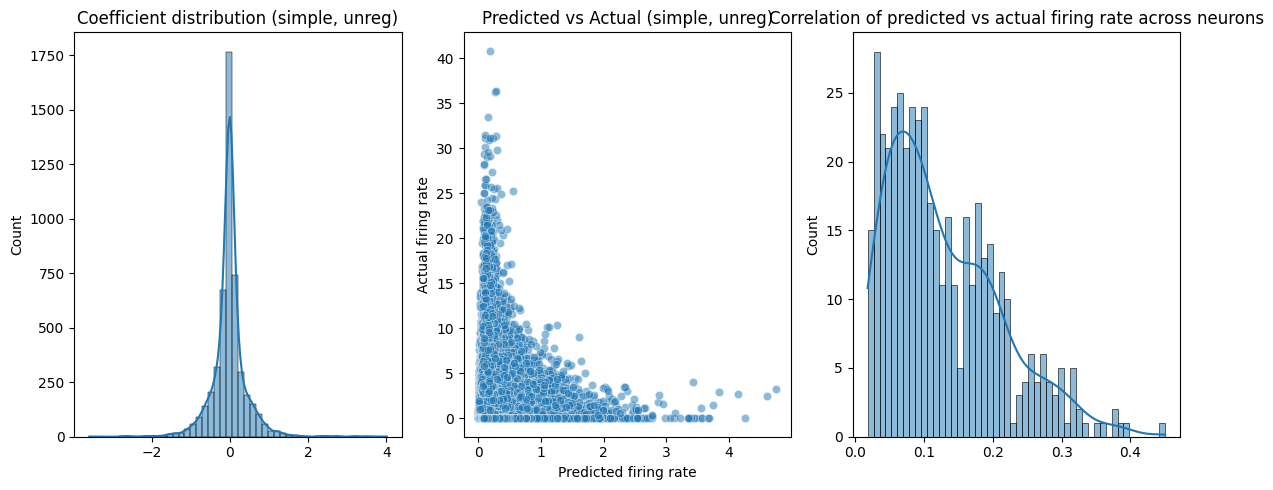

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
sns.histplot(model_simple_new.coef_.flatten(), bins=50, kde=True)
plt.title("Coefficient distribution (simple, unreg)")
plt.subplot(1, 3, 2)
sns.scatterplot(x=model_simple_new.predict(X_simple_new).flatten(), y=Y_new.flatten(), alpha=0.5)
plt.xlabel("Predicted firing rate")
plt.ylabel("Actual firing rate")
plt.title("Predicted vs Actual (simple, unreg)")
plt.tight_layout()
# Plot the correlation of the actual and predicted firing rate over all time steps for each neuron as a histogram
plt.subplot(1,3,3)
correlations = np.corrcoef(model_simple_new.predict(X_simple_new).T, Y_new.T)[:Y_new.shape[1], Y_new.shape[1]:]
sns.histplot(correlations.diagonal(), bins=50, kde=True)
plt.title("Correlation of predicted vs actual firing rate across neurons")  
plt.show()

In [13]:
# ---- 2. Unregularized Poisson PopGLM (complex) New ----
print("Fitting unregularized Poisson GLM (complex design matrix)...")
model_complex_new = nmo.glm.PopulationGLM(
    observation_model='Poisson',
    solver_name='LBFGS',
    solver_kwargs={'maxiter': 15000}
)
model_complex_new = model_complex_new.fit(X_complex_new, Y_new)
print("Done! coef shape:", model_complex_new.coef_.shape)

r2_complex_new = model_complex_new.score(X_complex_new, Y_new, score_type="pseudo-r2-McFadden")
print(f"Pseudo R-squared (complex, unreg): {r2_complex_new:.4f}")

Fitting unregularized Poisson GLM (complex design matrix)...


/n/data2/hms/neurobio/harvey/akshay/conda/envs/glm/lib/python3.11/site-packages/nemos/glm/glm.py:751: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


Done! coef shape: (217, 456)
Pseudo R-squared (complex, unreg): 0.1050


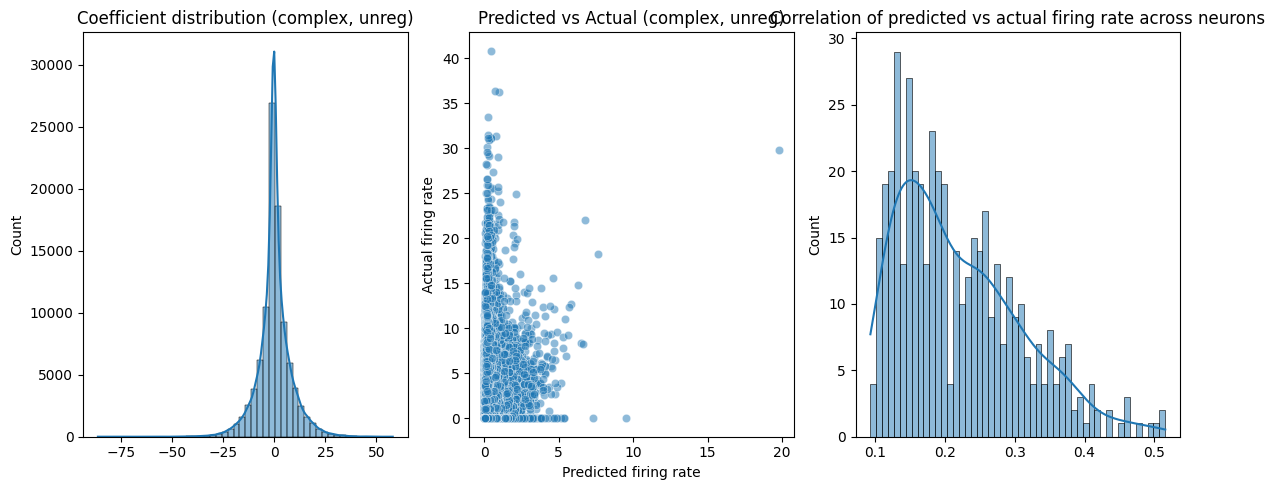

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
sns.histplot(model_complex_new.coef_.flatten(), bins=50, kde=True)
plt.title("Coefficient distribution (complex, unreg)")
plt.subplot(1, 3, 2)
sns.scatterplot(x=model_complex_new.predict(X_complex_new).flatten(), y=Y_new.flatten(), alpha=0.5)
plt.xlabel("Predicted firing rate")
plt.ylabel("Actual firing rate")
plt.title("Predicted vs Actual (complex, unreg)")
plt.tight_layout()
# Plot the correlation of the actual and predicted firing rate over all time steps for each neuron as a histogram
plt.subplot(1,3,3)
correlations = np.corrcoef(model_complex_new.predict(X_complex_new).T, Y_new.T)[:Y_new.shape[1], Y_new.shape[1]:]
sns.histplot(correlations.diagonal(), bins=50, kde=True)
plt.title("Correlation of predicted vs actual firing rate across neurons")  
plt.show()

In [ ]:
# ---- 3. GroupLasso Gamma PopGLM (complex) ----
# Build group mask: (n_groups, n_features, n_neurons)
n_features_complex = X_complex_new.shape[1]
n_neurons = Y_new.shape[1]

# Compute group boundaries
trial_level_names = (['world','turn_right', 'correct', 'prev_correct','prev_world'])
trial_indicator_names = trial_level_names
n_trial_indicators = len(trial_indicator_names)
n_continuous = 6  # pitch, roll, yaw, dpitch, droll, dyaw

n_groups = n_trial_indicators + n_continuous
group_mask = np.zeros((n_groups, n_features_complex, n_neurons))
idx = 0
for g in range(n_trial_indicators):
    group_mask[g, idx:idx + 35, :] = 1  # 20 spatial + 15 temporal
    idx += 35
for g in range(n_continuous):
    group_mask[n_trial_indicators + g, idx:idx + 7, :] = 1  # 7 bspline
    idx += 7

print(f"GroupLasso mask shape: {group_mask.shape}")
print(f"Total features covered: {idx} / {n_features_complex}")
assert idx == n_features_complex, f"Mismatch: {idx} != {n_features_complex}"

gl_regularizer = nmo.regularizer.GroupLasso(mask=group_mask)

print("Fitting GroupLasso Poisson GLM (complex design matrix)...")
model_gl = nmo.glm.PopulationGLM(
    observation_model='Poisson',
    regularizer=gl_regularizer,
    regularizer_strength=0.00,
    solver_name='ProximalGradient',
    solver_kwargs={'maxiter': 20000}
)
model_gl = model_gl.fit(X_complex_new, Y_new)
print("Done! coef shape:", model_gl.coef_.shape)

r2_gl = model_gl.score(X_complex_new, Y_new, score_type="pseudo-r2-McFadden")
print(f"Pseudo R-squared (complex, GroupLasso): {r2_gl:.4f}")

# Compare all models
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"  Simple (unreg):        R2 = {r2_simple_new:.4f}")
print(f"  Complex (unreg):       R2 = {r2_complex_new:.4f}")
print(f"  Complex (GroupLasso):  R2 = {r2_gl:.4f}")

GroupLasso mask shape: (11, 217, 456)
Total features covered: 217 / 217
Fitting GroupLasso Poisson GLM (complex design matrix)...


## Section E: Analyze — Clustering and PCA of Weight Matrix

Cluster neurons by their GLM weight profiles and visualize in PCA space.

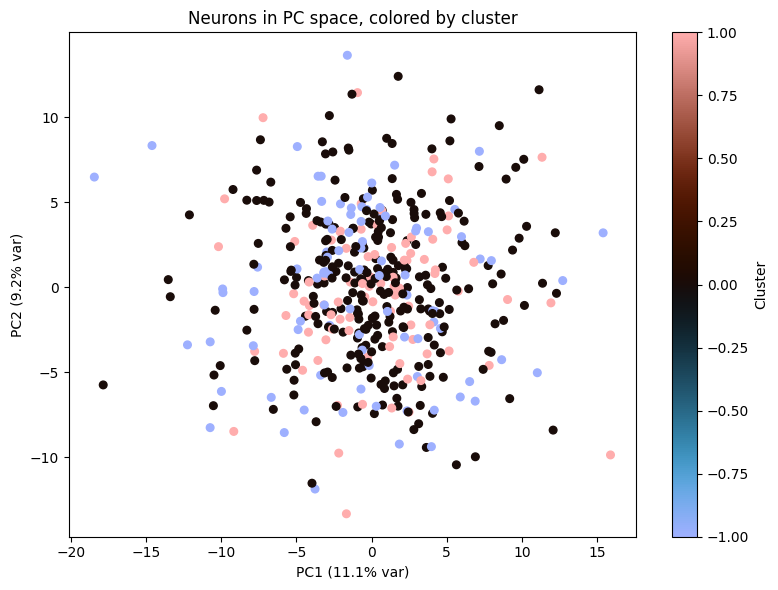

Cluster sizes: [105  96 118  40  97]
Top 5 PCA variance ratios: [0.11061227 0.09219896 0.06327423 0.06245599 0.05639991]


In [19]:
from sklearn.preprocessing import StandardScaler

# Use the GroupLasso model weights for analysis
W = np.array(model_complex_new.coef_)  # (n_features, n_neurons)
W_T = W.T  # (n_neurons, n_features) — each row is a neuron's weights

# ---- Clustering ----
W_scaled = StandardScaler().fit_transform(W_T)

# K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(W_scaled)

# ---- PCA ----
pca = PCA(n_components=10)
W_pca = pca.fit_transform(W_scaled)

# Color the PCA plot by fos high and fos low status
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fos_high = adata_binned_new.var['fosHigh+'].values.astype(int)
fos_low = adata_binned_new.var['fosLow+'].values.astype(int)
fos_status = fos_high - fos_low  # 1 for high, -1 for low, 0 for neither
scatter = ax.scatter(
    W_pca[:, 0], W_pca[:, 1],
    c=fos_status, cmap='berlin', s=30
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Neurons in PC space, colored by cluster')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'pca_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Cluster sizes: {np.bincount(cluster_labels)}")
print(f"Top 5 PCA variance ratios: {pca.explained_variance_ratio_[:5]}")

In [21]:
# List the top five features and bottom five features for each pc axis
n_top = 5
for i in range(3):
    pc_loadings = pca.components_[i]  # (n_features,)
    top_indices = np.argsort(np.abs(pc_loadings))[-n_top:]
    bottom_indices = np.argsort(np.abs(pc_loadings))[:n_top]
    print(f"\nPC{i+1} top features:")
    for idx in top_indices:
        print(f"  {complex_feature_names[idx]}: loading={pc_loadings[idx]:.4f}")
    print(f"PC{i+1} bottom features:")
    for idx in bottom_indices:
        print(f"  {complex_feature_names[idx]}: loading={pc_loadings[idx]:.4f}")


PC1 top features:
  correct_spatial_9: loading=0.1621
  correct_spatial_7: loading=0.1624
  correct_spatial_8: loading=-0.1625
  prev_correct_spatial_9: loading=-0.1641
  prev_correct_spatial_8: loading=0.1647
PC1 bottom features:
  turn_right_temporal_11: loading=0.0002
  prev_world_spatial_15: loading=-0.0002
  prev_world_temporal_6: loading=0.0002
  prev_world_spatial_16: loading=-0.0003
  roll_bspline_6: loading=-0.0004

PC2 top features:
  prev_correct_temporal_10: loading=0.1766
  prev_correct_temporal_9: loading=-0.1783
  prev_correct_temporal_7: loading=-0.1798
  prev_correct_temporal_8: loading=0.1803
  prev_correct_temporal_6: loading=0.1809
PC2 bottom features:
  world_temporal_9: loading=0.0001
  world_temporal_0: loading=-0.0002
  correct_spatial_18: loading=-0.0003
  world_temporal_11: loading=0.0004
  roll_bspline_1: loading=-0.0005

PC3 top features:
  world_spatial_7: loading=-0.1575
  turn_right_spatial_5: loading=0.1627
  turn_right_spatial_6: loading=-0.1657
  worl

In [ ]:
# ---- Feature importance: top 5 and bottom 5 ----
# Aggregate feature weights by GROUP
group_weights = []
group_names_list = list(trial_indicator_names) + list(continuous_names)

idx = 0
for g, name in enumerate(group_names_list):
    if g < n_trial_indicators:
        n_feat = 35
    else:
        n_feat = 7
    group_w = np.mean(np.abs(W[idx:idx + n_feat, :]))
    group_weights.append(group_w)
    idx += n_feat

group_weights = np.array(group_weights)
sorted_idx = np.argsort(group_weights)
top5 = sorted_idx[-5:][::-1]
bottom5 = sorted_idx[:5]
selected = np.concatenate([top5, bottom5])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue'] * 5 + ['salmon'] * 5
ax.bar(range(10), group_weights[selected], color=colors)
ax.set_xticks(range(10))
ax.set_xticklabels([group_names_list[i] for i in selected], rotation=45, ha='right')
ax.set_ylabel('Mean |Weight|')
ax.set_title('Top 5 and Bottom 5 Feature Groups by Weight Strength')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print all groups sorted
for i in sorted_idx[::-1]:
    print(f"  {group_names_list[i]:30s}  {group_weights[i]:.6f}")

## Section F: Extend — Fos High vs Fos Low Analysis

Compare GLM weight profiles between Fos High and Fos Low neurons using t-tests and a volcano plot.

In [22]:
# ---- Group neurons by Fos status ----
fos_high = adata_binned_new.var['fosHigh+'].values.astype(bool)
fos_low = adata_binned_new.var['fosLow+'].values.astype(bool)
fos_neither = ~fos_high & ~fos_low

print(f"Fos High: {fos_high.sum()}, Fos Low: {fos_low.sum()}, Neither: {fos_neither.sum()}")

# Weight matrix: (n_features, n_neurons)
W = np.array(model_complex_new.coef_)

# Group weights
W_high = W[:, fos_high]  # (n_features, n_fos_high)
W_low = W[:, fos_low]    # (n_features, n_fos_low)

# For every individual feature, find the difference between the fos low and high weight and run a t-test
p_values = []
p_stats = []
for i in range(W.shape[0]):
    stat, p = stats.ttest_ind(W_high[i, :], W_low[i, :], equal_var=False)
    p_values.append(p) 
    p_stats.append(stat)
p_values = np.array(p_values)
# Correct for multiple comparisons using Benjamini-Hochberg
#from statsmodels.stats.multitest import multipletests
#reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')


Fos High: 92, Fos Low: 92, Neither: 272


In [23]:
results_df = pd.DataFrame({
    'feature': complex_feature_names,
    'p_value': p_values,
    'diff': p_stats,
    #'reject': reject,
    #'p_value_corrected': pvals_corrected
})
results_df = results_df.sort_values('p_value')
results_df['neg_log10_p'] = -np.log10(results_df['p_value'] + 1e-10)
print(results_df.head(20))

                   feature   p_value      diff  neg_log10_p
203        droll_bspline_0  0.009987  2.606002     2.000557
180        pitch_bspline_5  0.032056 -2.160358     1.494086
34       world_temporal_14  0.039684 -2.071907     1.401383
213         dyaw_bspline_3  0.048226  1.988775     1.316716
206        droll_bspline_3  0.048575 -1.985829     1.313587
175        pitch_bspline_0  0.051017  1.971968     1.292282
167  prev_world_temporal_7  0.065839  1.851579     1.181516
193          yaw_bspline_4  0.074946  1.794170     1.125251
204        droll_bspline_1  0.075002 -1.790922     1.124930
33       world_temporal_13  0.078160  1.771578     1.107014
152  prev_world_spatial_12  0.078170 -1.771386     1.106958
191          yaw_bspline_2  0.082750  1.748245     1.082233
21        world_temporal_1  0.083866  1.738522     1.076413
22        world_temporal_2  0.088760 -1.711673     1.051781
168  prev_world_temporal_8  0.105948 -1.624972     0.974908
185         roll_bspline_3  0.109032  1.

In [ ]:
# ---- Volcano plot ----
fig, ax = plt.subplots(figsize=(10, 7))
sig_mask = results_df['p_value'] < 0.05
ax.scatter(
    results_df.loc[~sig_mask, 'diff'], results_df.loc[~sig_mask, 'neg_log10_p'],
    c='gray', alpha=0.6, s=50, label='Not significant'
)
ax.scatter(
    results_df.loc[sig_mask, 'diff'], results_df.loc[sig_mask, 'neg_log10_p'],
    c='red', alpha=0.8, s=80, label='p < 0.05'
)

# Label significant points
for _, row in results_df[sig_mask].iterrows():
    ax.annotate(
        row['feature'], (row['diff'], row['neg_log10_p']),
        fontsize=8, ha='center', va='bottom'
    )

ax.axhline(y=-np.log10(0.05), color='gray', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean |Weight| Difference (Fos High - Fos Low)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot: Feature Weight Differences\nFos High vs Fos Low Neurons')
ax.legend()
plt.tight_layout()
#plt.savefig(os.path.join(out_dir, 'volcano_fos.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save results
#results_df.to_csv(os.path.join(out_dir, 'fos_feature_comparison.csv'), index=False)
print("Results saved!")

In [16]:
# Combine obs with dcnv_norm into one dataframe
adata_combined = pd.concat([
    adata_binned_new.obs.reset_index(drop=True),
    pd.DataFrame(adata_binned_new.layers['dcnv_norm'], columns=[f'neuron_{i}' for i in range(adata_binned_new.layers['dcnv_norm'].shape[1])])
], axis=1)
adata_combined['predicted'] = False
predicted = pd.concat([
    adata_binned_new.obs.reset_index(drop=True),
    pd.DataFrame(model_complex_new.predict(X_complex_new), columns=[f'neuron_{i}' for i in range(adata_binned_new.layers['dcnv_norm'].shape[1])])
], axis=1)
predicted['predicted'] = True
adata_combined = pd.concat([adata_combined, predicted], axis=0).reset_index(drop=True)
adata_combined.loc[adata_combined['is_iti']==True,'spatial_bin'] += n_spatial_bins
adata_melted = adata_combined.melt(
    id_vars=['trial_id', 'spatial_bin', 'is_iti', 'world','correct','predicted'],
    value_vars=[f'neuron_{i}' for i in range(adata_binned_new.layers['dcnv_norm'].shape[1])],
    var_name='neuron',
    value_name='dcnv_norm'
)

In [33]:
corr_sorted_i = np.argsort(correlations.diagonal())[::-1]
corr_extremes = corr_sorted_i[:5].tolist()
corr_extreme_names = [f'neuron_{i}' for i in corr_extremes]
adata_melted_extremes_correct = adata_melted.loc[adata_melted['correct']==True].loc[adata_melted['neuron'].isin(corr_extreme_names)]

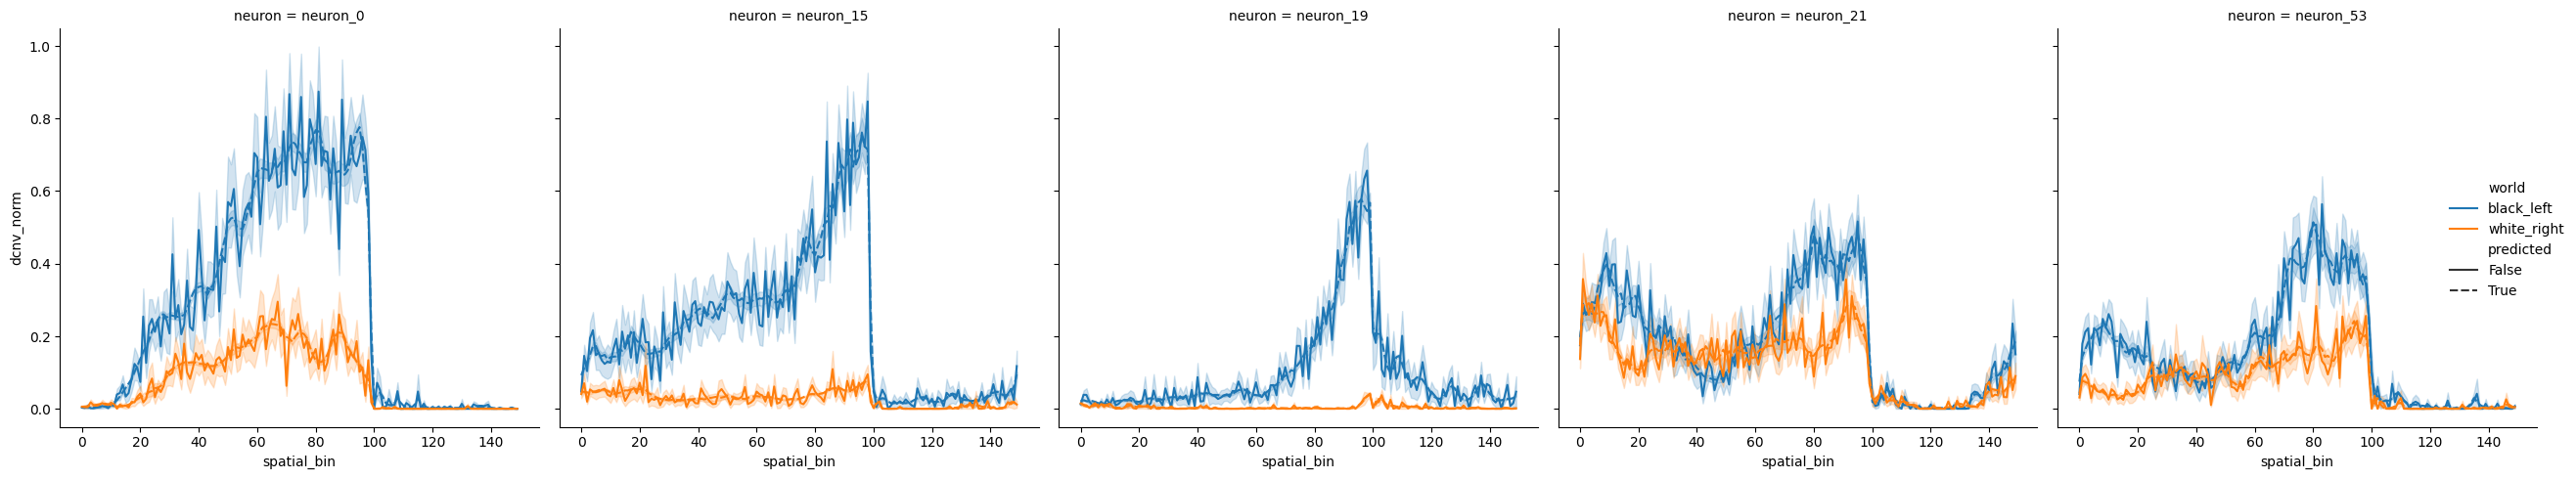

In [34]:
g = sns.relplot(
    data=adata_melted_extremes_correct,
    kind="line",
    x='spatial_bin',
    y="dcnv_norm",
    col="neuron",
    hue="world",
    style="predicted",  
    estimator="mean",
    errorbar="se", 
    dashes=True,
    markers=False,
)
g.add_legend()
plt.show()

In [41]:
# print the top three and bottom three weighted features for each of the top five neurons with highest corr
for i in corr_extremes:
    neuron_name = f'neuron_{i}'
    print(f"\nNeuron: {neuron_name}, Correlation: {correlations.diagonal()[i]:.4f}")
    neuron_weights = W[:, i]
    top_indices = np.argsort(neuron_weights)[-3:][::-1]
    bottom_indices = np.argsort(neuron_weights)[:3]
    print("  Top 3 features:")
    for idx in top_indices:
        print(f"    {complex_feature_names[idx]}: weight={neuron_weights[idx]:.4f}")
    print("  Bottom 3 features:")
    for idx in bottom_indices:
        print(f"    {complex_feature_names[idx]}: weight={neuron_weights[idx]:.4f}")


Neuron: neuron_21, Correlation: 0.5158
  Top 3 features:
    prev_correct_temporal_9: weight=8.2742
    turn_right_spatial_19: weight=7.7521
    turn_right_spatial_13: weight=7.7086
  Bottom 3 features:
    prev_correct_temporal_8: weight=-9.3303
    turn_right_spatial_14: weight=-7.5772
    prev_correct_temporal_10: weight=-7.4861

Neuron: neuron_15, Correlation: 0.5153
  Top 3 features:
    world_temporal_3: weight=25.4993
    world_temporal_1: weight=22.5588
    turn_right_temporal_3: weight=20.2742
  Bottom 3 features:
    yaw_bspline_6: weight=-46.7167
    world_temporal_4: weight=-38.7131
    turn_right_temporal_4: weight=-24.9043

Neuron: neuron_53, Correlation: 0.4993
  Top 3 features:
    correct_temporal_7: weight=14.1736
    prev_world_temporal_10: weight=12.2222
    world_temporal_13: weight=9.7373
  Bottom 3 features:
    yaw_bspline_6: weight=-49.3097
    prev_correct_temporal_7: weight=-18.4914
    world_temporal_7: weight=-13.3627

Neuron: neuron_19, Correlation: 0.491